## Obserwacje z zad 1

W EDA korzystałem bardzo dużo z macierzy korelacji i pozbyłem się cech które mają bardzo małą korelacje z cechą survived i dodatkowo utworzyłem cechy które mają w miare rozsądny poziom tej korelacji

Bezużyteczne były cechy takie jak:
- Name

Cechy które wymagały zmiany:
- Cabin
- Embarked
- Ticket
- Parch
- SibSp
- Age

Cechy które były przydatne same z siebie:
- Fare
- Pclass
- Survived
- Sex

Utworzyłem takie klasy jak:
- HasCabin
- IsAlone(uwzględniające FamilySize ale też TicketSize)
- HasAge
- AgeCat

Wiemy tez ze nie wszystkie Cechy mają rozkład Normalny co znaczy że danych nie możemy ustandaryzowac(Do skalowania użyje RobustScalera zeby zabezpieczyć się przed Skrajnymi wartosciami)

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
path = Path.cwd() / "titanic_cleaned.csv"
titanic_df = pd.read_csv(path, index_col='PassengerId')

Zacznijmy od podstawowych czynności:
- Oddzielenie label od reszty cech
- wyskalowanie danych
- podział na zbiór testowy, treningowy oraz walidacyjny


In [84]:
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]
labels = X.columns

transformer = sk.preprocessing.RobustScaler()
X = transformer.fit_transform(X)

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, train_size=.8, shuffle=True)


wytrenujmy sobie dummy classifiera

In [85]:
model_dum = DummyClassifier(strategy = 'uniform')
model_dum.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'uniform'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.61,0.39]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,9
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


Napiszmy sobie funkcje Benchmark która będzie sprawdzała jakość danego modelu

Jako kluczowe metryki oceniania wybrałem:
- F1 score (Mierzy średnią Precyzji (Precision) i Czułości (Recall). Daje rzetelną ocenę jakości klasyfikacji dla grupy Survived na niezbalansowanym zbiorze)
- ROC-AUC (Niezależnie od wybranego progu odcięcia, pozwala obiektywnie ocenić jakość rankingowania prawdopodobieństw)
- Confusion Matrix(poglądowo)

In [86]:
def Benchmark(model, ref=False, X_test=X_test, y_test=y_test):
    y_pred = model.predict(X_test)

    # Rysowanie krzywej dla głównego modelu
    plt.plot(*roc_curve(y_test, y_pred)[:2], label="Model")

    if ref:
        y_pred_ref = ref.predict(X_test)
        print("Model - F1:", f1_score(y_test, y_pred), "AUC:", roc_auc_score(y_test, y_pred))
        print("Ref - F1:", f1_score(y_test, y_pred_ref), "AUC:", roc_auc_score(y_test, y_pred_ref))
        print("Model CM:\n", confusion_matrix(y_test, y_pred))
        print("Ref CM:\n", confusion_matrix(y_test, y_pred_ref))


        plt.plot(*roc_curve(y_test, y_pred_ref)[:2], label="Ref", linestyle="--")
    else:
        print("F1:", f1_score(y_test, y_pred), "AUC:", roc_auc_score(y_test, y_pred))
        print(confusion_matrix(y_test, y_pred))

    plt.legend()
    plt.show()

F1: 0.37410071942446044 AUC: 0.48895790200138023
[[65 50]
 [37 26]]


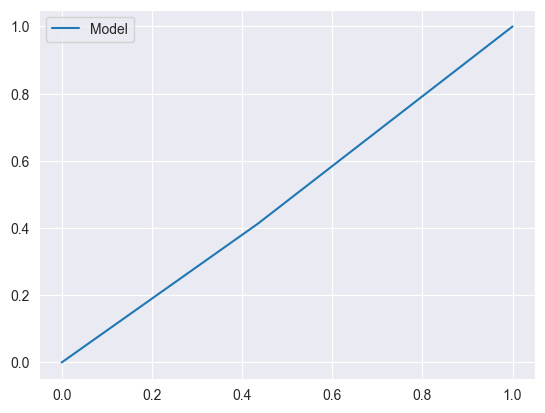

In [87]:
Benchmark(model_dum)

no i widzimy za pomocą funkcji benchmark że dummy_classifier nie rózni nam sie od losowego wybierania a nawet wydaje sie troche gorsze(zależy jak polosuje)

jako pierwszy model wybierzemy sobie random forest

Model - F1: 0.7394957983193278 AUC: 0.7970324361628709
Ref - F1: 0.32894736842105265 AUC: 0.420151828847481
Model CM:
 [[103  12]
 [ 19  44]]
Ref CM:
 [[51 64]
 [38 25]]


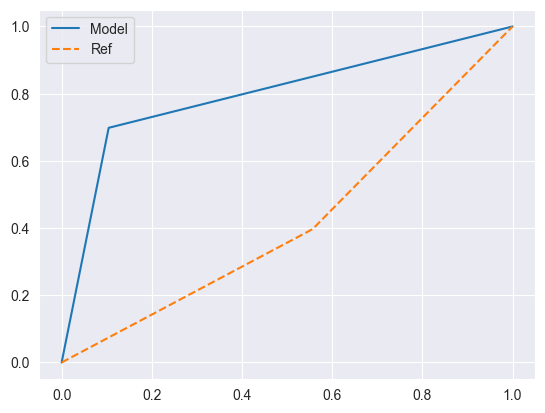

In [88]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
Benchmark(model,model_dum)

Jako następny model Wybieram KNN z odległością cosinusową(cosinusowa bo zależy nam na wychwytywaniu poszczególnych zależności a nie na odległości w rozumieniu euklidesowym)

Model - F1: 0.6614173228346457 AUC: 0.7376811594202898
Ref - F1: 0.3790849673202614 AUC: 0.46494133885438227
Model CM:
 [[93 22]
 [21 42]]
Ref CM:
 [[54 61]
 [34 29]]


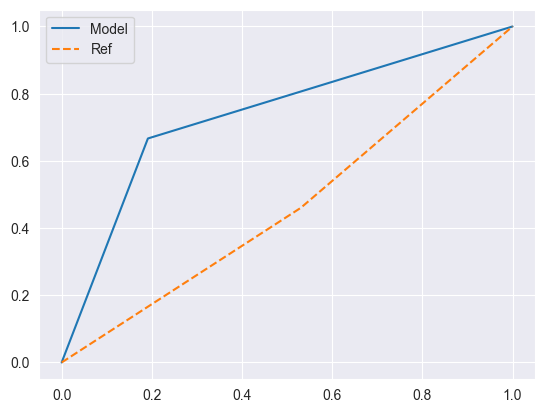

In [89]:
from sklearn.neighbors import KNeighborsClassifier
# KNN z metryką cosine similarity
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn.fit(X_train, y_train)
Benchmark(knn,model_dum)

# Porównanie KNN z RandomForest

KNN jako model główny i RandomForest jako referencyjny

Model - F1: 0.6614173228346457 AUC: 0.7376811594202898
Ref - F1: 0.7394957983193278 AUC: 0.7970324361628709
Model CM:
 [[93 22]
 [21 42]]
Ref CM:
 [[103  12]
 [ 19  44]]


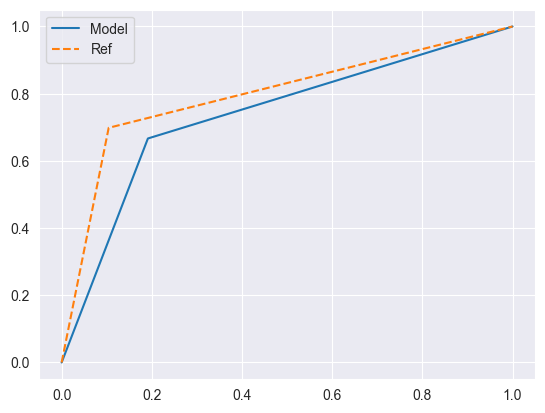

In [90]:
Benchmark(knn,model)

Widzimy że KNN radzi sobie troche lepiej

Natomiast wydaje mi się że dałoby się uzyskać troche lepszy wynik Sprawdźmy jak rasdzi sobie SVM

SVC(bazowy)

KNN(referencyyjny)

Model - F1: 0.7096774193548387 AUC: 0.7752933057280882
Ref - F1: 0.6614173228346457 AUC: 0.7376811594202898
Model CM:
 [[98 17]
 [19 44]]
Ref CM:
 [[93 22]
 [21 42]]


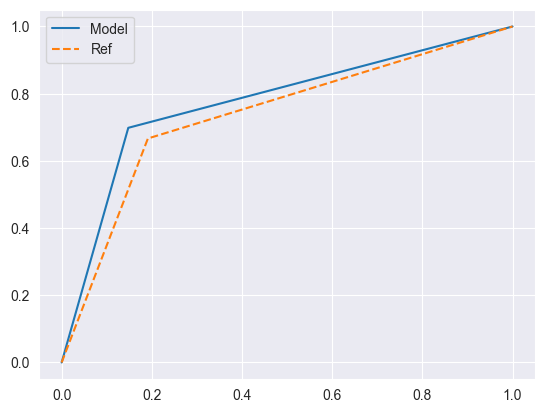

In [91]:
from sklearn.svm import SVC
clf = SVC(kernel='linear')  # liniowe SVM
clf.fit(X_train, y_train)
Benchmark(clf,knn)

Z tego co Widzimy knn dalej jest na topie


Porównajmy sobie te modely przy cross validation

dodatkowo wprowadzam liczenie AUC z proba żeby nie zaniżać wyników

In [92]:
from sklearn.model_selection import cross_val_predict

def Benchmark_CV(model, ref=False, X=X, y=y, cv=5):
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    plt.plot(*roc_curve(y, y_proba)[:2], label="Model")

    if ref:
        y_proba_ref = cross_val_predict(ref, X, y, cv=cv, method='predict_proba')[:, 1]
        y_pred_ref = (y_proba_ref >= 0.5).astype(int)
        print("Model - F1:", f1_score(y, y_pred), "AUC:", roc_auc_score(y, y_proba))
        print("Ref - F1:", f1_score(y, y_pred_ref), "AUC:", roc_auc_score(y, y_proba_ref))
        print("Model CM:\n", confusion_matrix(y, y_pred))
        print("Ref CM:\n", confusion_matrix(y, y_pred_ref))

        plt.plot(*roc_curve(y, y_proba_ref)[:2], label="Ref", linestyle="--")
    else:
        print("F1:", f1_score(y, y_pred), "AUC:", roc_auc_score(y, y_proba))
        print(confusion_matrix(y, y_pred))

    plt.legend()
    plt.show()

teraz sprawdzmy porownanie KNN z Random forest

Model - F1: 0.7053571428571429 AUC: 0.8171648987463838
Ref - F1: 0.7272727272727273 AUC: 0.847800814314797
Model CM:
 [[454  95]
 [103 237]]
Ref CM:
 [[469  80]
 [100 240]]


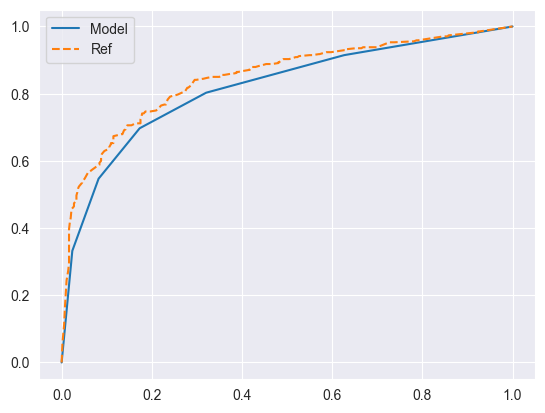

In [94]:
Benchmark_CV(knn,model)

Widzimy ze tutaj modele wyszly bardziej do siebie zbliżone(z lekką przewagą RandomForest)
Sprawdzmy jeszcze Random Forest

sprawdźmy sobie jeszcze XGboosta(porównując go do random forest)

Model - F1: 0.7303543913713405 AUC: 0.8390496089146041
Ref - F1: 0.7225609756097561 AUC: 0.8430810028929606
Model CM:
 [[477  72]
 [103 237]]
Ref CM:
 [[470  79]
 [103 237]]


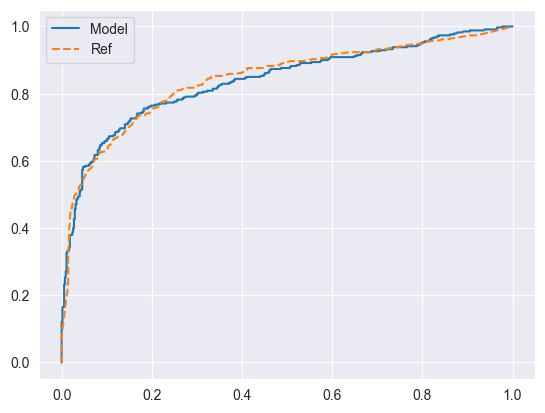

In [95]:
from xgboost import XGBClassifier
XGBC = XGBClassifier()
Benchmark_CV(XGBC,model)

widzimy że XGboost jest lekko lepszy od RandomFotest pod względem F1 score ale gorszym pod wzgledem AUC

z tego powodu spróbuje zoptymalizować hiperparametry obu i porównamje jeszcze raz

# Optymalizacja hiperparametrów
Random Forest:
- max depth(3-10)
- min_samples_leaf(1-6)
- min_samples_split(2-10)
- n_estimators(50-300)

XGBoost:
- max depth(2-6)
- learning rate(0.01-0.2)
- subsample(0.6-1)
- colsample bytree(0.6-1)

optymalizujemy pod AUC bo jednak jest trovhe bardziej przewidywalne dzieki temu że używa proba


In [97]:
import optuna
from sklearn.model_selection import cross_val_score

# Wyciszenie logów Optuny, żeby nie zasypywać konsoli
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    # Optymalizujemy średnią wartość AUC z 5-fold CV
    return cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=40)

print("Najlepsze AUC dla Random Forest:", round(study_rf.best_value, 4))
print("Najlepsze parametry RF:", study_rf.best_params)

Najlepsze AUC dla Random Forest: 0.8626
Najlepsze parametry RF: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1}


In [98]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBClassifier(**params)
    return cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=40)

print("Najlepsze AUC dla XGBoost:", round(study_xgb.best_value, 4))
print("Najlepsze parametry XGBoost:", study_xgb.best_params)

Najlepsze AUC dla XGBoost: 0.8651
Najlepsze parametry XGBoost: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.06681354645550217, 'subsample': 0.7581139408156309, 'colsample_bytree': 0.6260524921860781}


dobra to teraz ładujemy hiperparametry do modeli i sprawdzamy
(Główny model to Random forest a referencyjny XGBOOST)

Model - F1: 0.7369942196531792 AUC: 0.8585904853744777
Ref - F1: 0.7346938775510204 AUC: 0.8619414979106398
Model CM:
 [[452  97]
 [ 85 255]]
Ref CM:
 [[486  63]
 [106 234]]


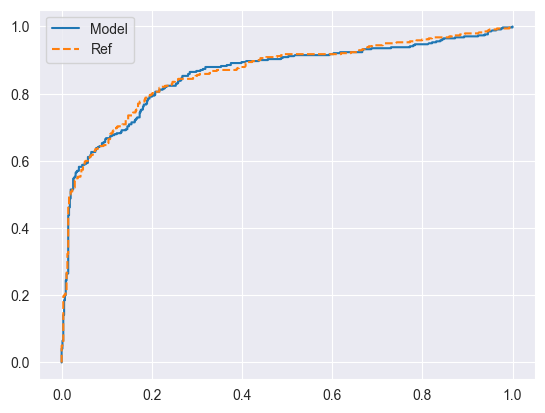

In [99]:
RandomForest = RandomForestClassifier(
    n_estimators=250,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

XGBoost = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.06681354645550217,
    subsample=0.7581139408156309,
    colsample_bytree=0.6260524921860781,
    eval_metric='logloss',
    random_state=42,
    n_jobs=1
)

Benchmark_CV(RandomForest,XGBoost)

Widzimy że modele znowu wypadły podobnie(jeden ma wiekszy f1 score 2 wieksze AUC)

Tu trzeba odpowiedzieć sobie na pytanie co jest dla nas ważniejsze, ja bym powiedział że ważniejszy jest mimo wszystko AUC gdyż tak jak mówiłem daje nam bardziej pewny wynik.

Z tego też wynika że XGBoost to jest mój najlepszy model z wynikiem
f1: 0.734
AUC: 0.861

Dodatkową zaletą (bądź wadą – w zależności od przyjętego kontekstu biznesowego) jest fakt, że model generuje mniej fałszywych alarmów ($FP$) niż przeoczeń ($FN$). Oznacza to, że rzadziej błędnie prognozuje przeżycie osobie, która w rzeczywistości zginie, niż uznaje za zmarłą osobę, która przeżyje, jeżeli to miałby być klasyfikator według którego mamy wpuścić ludzi na statek to lepiej pogodzić się z tym że na statek nie wejdziemy(pomimo tego że byśmy nie umarli) niż z tym że umrzemy(pomimo tego że model wskazał że przeżyjemy).